# Tutorial: Build And Inspect A Terminal Benchmark Release

This notebook walks through the full benchmark workflow for one horizon-specific terminal release.

By the end you will have:
- one frozen release such as `polymarket-terminal-24h`
- `train_df`, `train_target`, `test_df`, and `test_target`
- a simple way to inspect one market's visible history up to its cutoff
- a baseline evaluation on the fixed test split


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from polymarket_research.benchmarks import TerminalBenchmark, TerminalBenchmarkConfig
from polymarket_research.data.canonical import CanonicalDataset
from polymarket_research.utils.filesystem import setup_root

# Choose one release horizon for this tutorial run.
REPO_ROOT = setup_root()
DATA_SOURCE = 'polymarket'  # or 'kalshi'
ARTEFACT_ROOT = REPO_ROOT / 'frozen_notebooks' / 'running_artefacts' / DATA_SOURCE
CANONICAL_CACHE_DIR = ARTEFACT_ROOT / 'canonical_dataset'
RELEASE_HORIZON_HOURS = 24
RELEASE_NAME = f'{DATA_SOURCE}-terminal-{RELEASE_HORIZON_HOURS}h'
BENCHMARK_CACHE_DIR = ARTEFACT_ROOT / f'terminal_benchmark_{RELEASE_HORIZON_HOURS}h'
MARKET_LIMIT = None
MARKET_ORDER = None  # one of: None, 'latest', 'largest'
SHOW_PROGRESS = True
USE_BENCHMARK_CACHE = True
BENCHMARK_CONFIG = TerminalBenchmarkConfig(
    horizons_hours=(RELEASE_HORIZON_HOURS,),
    max_snapshot_staleness_hours=12.0,
    max_snapshot_staleness_hours_by_horizon={
        24: 12.0,
        72: 18.0,
        168: 24.0,
    },
    split_on='end_date',
    train_fraction=0.8,
    show_progress=SHOW_PROGRESS,
)

pd.set_option('display.max_colwidth', None)


## Step 1: Build Or Load One Release

Start from the canonical dataset, then either load a cached horizon-specific release or build it from scratch.

The important idea is that one notebook run corresponds to one benchmark release, for example `polymarket-terminal-24h`.


In [2]:
canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
print("Loaded canonical from parquet cache:", CANONICAL_CACHE_DIR)


Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/frozen_notebooks/running_artefacts/polymarket/canonical_dataset


In [3]:
if USE_BENCHMARK_CACHE and (BENCHMARK_CACHE_DIR / "examples.parquet").exists() and MARKET_LIMIT is None and MARKET_ORDER is None:
    terminal_benchmark = TerminalBenchmark.load(BENCHMARK_CACHE_DIR)
    print(f"Loaded {RELEASE_NAME} from parquet cache:", BENCHMARK_CACHE_DIR)
else:
    terminal_benchmark = TerminalBenchmark.build(canonical, config=BENCHMARK_CONFIG)
    if MARKET_LIMIT is None and MARKET_ORDER is None:
        terminal_benchmark.save(BENCHMARK_CACHE_DIR)
    print(f"Built {RELEASE_NAME} from canonical")

[terminal benchmark] starting (markets=15662, probability_rows=208040673, horizons=[24], split_on=end_date)
[terminal benchmark] validated canonical tables
[terminal benchmark] prepared inputs (markets=15662, probability_rows=208040673)
[terminal benchmark] indexed contiguous market blocks (markets_with_history=15662)


terminal examples:   0%|          | 0/15662 [00:00<?, ?market/s]

[terminal benchmark] built example manifest (examples=10156, train=7918, test=2238)


terminal market histories:   0%|          | 0/15662 [00:00<?, ?market/s]

[terminal benchmark] built market histories (market_timeseries_rows=144202396)
[terminal benchmark] done
Built polymarket-terminal-24h from canonical


In [4]:
# First inspect the raw canonical inputs, then the benchmark manifest metadata.
display(canonical.summary())
manifest = terminal_benchmark.manifest()
manifest_frame = pd.DataFrame([{"field": k, "value": repr(v) if isinstance(v, (list, dict, tuple)) else v} for k, v in manifest.items()])
display(manifest_frame)

,name,rows,cols
0,markets,15662,40
1,probabilities,208040673,7
2,external_covariates,263808,19
3,download_status,17247,18


,field,value
0,name,terminal_benchmark
1,release_name,polymarket-terminal-24h
2,task,terminal_outcome_prediction
3,observable_information,target market metadata and market-level probability history up to cutoff
4,target_type,final resolved outcome
5,config,"{'horizons_hours': [24], 'max_snapshot_staleness_hours': 12.0, 'max_snapshot_staleness_hours_by_horizon': {'24': 12.0, '72': 18.0, '168': 24.0}, 'split_on': 'end_date', 'split_timestamp_utc': None, 'train_fraction': 0.8, 'show_progress': True}"
6,rows,10156
7,market_timeseries_rows,144202396
8,split_counts,"{'test': 2238, 'train': 7918}"
9,horizons_hours,[24]


In [5]:
pd.DataFrame([
    {
        "release_name": terminal_benchmark.release_name,
        "market_timeseries_rows": len(terminal_benchmark.market_timeseries),
        "market_timeseries_columns": list(terminal_benchmark.market_timeseries.columns),
    }
])

,release_name,market_timeseries_rows,market_timeseries_columns
0,polymarket-terminal-24h,144202396,"[market_id, timestamp_utc, yes_probability]"


In [6]:
# Materialize the four main objects used by most training/evaluation workflows.
train_df = terminal_benchmark.split_examples("train")
train_target = terminal_benchmark.targets("train")
test_df = terminal_benchmark.split_examples("test")
test_target = terminal_benchmark.targets("test")

display(manifest_frame)
display(pd.DataFrame([{
    "train_examples": len(train_df),
    "test_examples": len(test_df),
    "train_targets": len(train_target),
    "test_targets": len(test_target),
}]))

,field,value
0,name,terminal_benchmark
1,release_name,polymarket-terminal-24h
2,task,terminal_outcome_prediction
3,observable_information,target market metadata and market-level probability history up to cutoff
4,target_type,final resolved outcome
5,config,"{'horizons_hours': [24], 'max_snapshot_staleness_hours': 12.0, 'max_snapshot_staleness_hours_by_horizon': {'24': 12.0, '72': 18.0, '168': 24.0}, 'split_on': 'end_date', 'split_timestamp_utc': None, 'train_fraction': 0.8, 'show_progress': True}"
6,rows,10156
7,market_timeseries_rows,144202396
8,split_counts,"{'test': 2238, 'train': 7918}"
9,horizons_hours,[24]


,train_examples,test_examples,train_targets,test_targets
0,7918,2238,7918,2238


## Step 2: Materialize The Four Main Objects


For most workflows, this is the shortest path that matters:
- `train_df`: frozen train manifest rows
- `train_target`: train labels
- `test_df`: frozen test manifest rows
- `test_target`: test labels

`market_timeseries` is separate and normalized by `market_id`. Treat it as source history for inspection, not as the first object to materialize into synthetic prefixes.


In [7]:
display(train_df.head())
display(train_target.head())
display(test_df.head())
display(test_target.head())


,market_id,market_slug,question,created_at,end_date,platform_category,research_category,family_id,horizon_hours,cutoff_timestamp_utc,label,split
0,517049,fact-check-cybertruck-explosion-caused-by-lithium-battery,Fact Check: Cybertruck explosion caused by lithium battery?,2025-01-01 20:59:09.882827+00:00,2025-01-03 12:00:00+00:00,<NA>,<NA>,unknown::::fact check cybertruck explosion caused lithium,24,2025-01-02 12:00:00+00:00,0,train
1,517050,fact-check-cybertruck-explosion-intentional,Fact Check: Cybertruck explosion intentional?,2025-01-01 21:14:29.220542+00:00,2025-01-03 12:00:00+00:00,<NA>,<NA>,unknown::::fact check cybertruck explosion intentional,24,2025-01-02 12:00:00+00:00,1,train
2,517052,cybertruck-explosion-perp-arrested-by-sunday,Cybertruck explosion perp arrested by Sunday?,2025-01-01 21:30:56.148587+00:00,2025-01-05 12:00:00+00:00,<NA>,<NA>,unknown::::cybertruck explosion perp arrested sunday,24,2025-01-04 12:00:00+00:00,0,train
3,517170,martial-law-in-south-korea-before-monday,Martial law in South Korea before Monday?,2025-01-02 23:18:47.351059+00:00,2025-01-05 12:00:00+00:00,<NA>,<NA>,unknown::::martial law south korea before monday,24,2025-01-04 12:00:00+00:00,0,train
4,517242,will-anora-win-the-golden-globe-for-best-musical-or-comedy,Will 'Anora' win the Golden Globe for Best Musical or Comedy?,2025-01-03 20:22:39.211851+00:00,2025-01-05 12:00:00+00:00,<NA>,<NA>,unknown::::anora win golden globe for best,24,2025-01-04 12:00:00+00:00,0,train


,market_id,horizon_hours,label,split
0,517049,24,0,train
1,517050,24,1,train
2,517052,24,0,train
3,517170,24,0,train
4,517242,24,0,train


,market_id,market_slug,question,created_at,end_date,platform_category,research_category,family_id,horizon_hours,cutoff_timestamp_utc,label,split
0,1004841,will-there-be-seven-or-eight-announced-new-us-armed-forces-strikes-against-drug-boats-by-january-31-2026,"Will there be seven or eight announced new U.S. armed forces strikes against drug boats by January 31, 2026?",2025-12-23 16:45:48.990332+00:00,2026-01-31 00:00:00+00:00,<NA>,<NA>,unknown::::there seven or eight announced new,24,2026-01-30 00:00:00+00:00,1,test
1,1004842,will-there-be-nine-or-ten-announced-new-us-armed-forces-strikes-against-drug-boats-by-january-31-2026,"Will there be nine or ten announced new U.S. armed forces strikes against drug boats by January 31, 2026?",2025-12-23 16:45:49.473013+00:00,2026-01-31 00:00:00+00:00,<NA>,<NA>,unknown::::there nine or ten announced new,24,2026-01-30 00:00:00+00:00,0,test
2,1004843,will-there-be-eleven-or-more-announced-new-us-armed-forces-strikes-against-drug-boats-by-january-31-2026,"Will there be eleven or more announced new U.S. armed forces strikes against drug boats by January 31, 2026?",2025-12-23 16:45:49.938377+00:00,2026-01-31 00:00:00+00:00,<NA>,<NA>,unknown::::there eleven or more announced new,24,2026-01-30 00:00:00+00:00,0,test
3,1007585,will-russia-enter-toretske-by-january-31,Will Russia enter Toretske by January 31?,2025-12-23 22:32:56.382901+00:00,2026-01-31 00:00:00+00:00,<NA>,<NA>,unknown::::russia enter toretske january 31,24,2026-01-30 00:00:00+00:00,0,test
4,1020644,clavicular-charged-by-jan-31,Clavicular charged by Jan 31?,2025-12-25 17:16:25.958503+00:00,2026-01-31 00:00:00+00:00,<NA>,<NA>,unknown::::clavicular charged jan 31,24,2026-01-30 00:00:00+00:00,0,test


,market_id,horizon_hours,label,split
0,1004841,24,1,test
1,1004842,24,0,test
2,1004843,24,0,test
3,1007585,24,0,test
4,1020644,24,0,test


In [8]:
# Peek at a few normalized market histories without creating synthetic per-example tables.
preview_market_ids = train_df.head(3)["market_id"]
train_timeseries_preview = terminal_benchmark.market_timeseries.loc[
    lambda df: df["market_id"].isin(preview_market_ids)
]
display(train_timeseries_preview.head(20))

,market_id,timestamp_utc,yes_probability
14950520,517049,2025-01-01 21:15:00+00:00,0.500000
14950521,517049,2025-01-01 21:20:00+00:00,0.250000
14950522,517049,2025-01-01 21:25:00+00:00,0.250000
14950523,517049,2025-01-01 21:30:00+00:00,0.060000
14950524,517049,2025-01-01 21:35:00+00:00,0.060000
14950525,517049,2025-01-01 21:40:00+00:00,0.040000
14950526,517049,2025-01-01 21:45:00+00:00,0.080000
14950527,517049,2025-01-01 21:50:00+00:00,0.070000
14950528,517049,2025-01-01 21:55:00+00:00,0.060000
14950529,517049,2025-01-01 22:00:00+00:00,0.040000


## Step 3: Inspect One Market End-To-End


The benchmark keeps the manifest row and market history separate on purpose.

The workflow is:
1. pick one `market_id` from the split manifest
2. resolve its benchmark row
3. fetch full market history
4. clip that history at the benchmark cutoff


In [9]:
# Pick one held-out market and inspect exactly what history was visible at the cutoff.
market_id = test_df.sample().iloc[0]["market_id"]
example = terminal_benchmark.resolve_market_id(market_id)
observation = terminal_benchmark.market_history(market_id).loc[
    lambda df: df["timestamp_utc"] <= example["cutoff_timestamp_utc"]
]

display(pd.DataFrame([
    {
        "market_id": example["market_id"],
        "horizon_hours": example["horizon_hours"],
        "cutoff_timestamp_utc": example["cutoff_timestamp_utc"],
        "prefix_rows": len(observation),
    }
]))
display(example.to_frame(name="value"))
display(observation.tail())
display(test_target.loc[lambda df: df["market_id"] == market_id])


,market_id,horizon_hours,cutoff_timestamp_utc,prefix_rows
0,1632731,24,2026-03-30 00:00:00+00:00,3374


,value
market_id,1632731
market_slug,will-israel-conduct-military-action-in-greater-beirut-on-march-28-2026
question,"Will Israel conduct military action in Greater Beirut on March 28, 2026?"
created_at,2026-03-17 22:09:40.769363+00:00
end_date,2026-03-31 00:00:00+00:00
platform_category,<NA>
research_category,<NA>
family_id,unknown::::israel conduct military action greater beirut
horizon_hours,24
cutoff_timestamp_utc,2026-03-30 00:00:00+00:00


,market_id,timestamp_utc,yes_probability
3369,1632731,2026-03-29 23:40:00+00:00,0.408000
3370,1632731,2026-03-29 23:45:00+00:00,0.408000
3371,1632731,2026-03-29 23:50:00+00:00,0.408000
3372,1632731,2026-03-29 23:55:00+00:00,0.401108
3373,1632731,2026-03-30 00:00:00+00:00,0.401108


,market_id,horizon_hours,label,split
1958,1632731,24,0,test


<Axes: xlabel='timestamp_utc'>

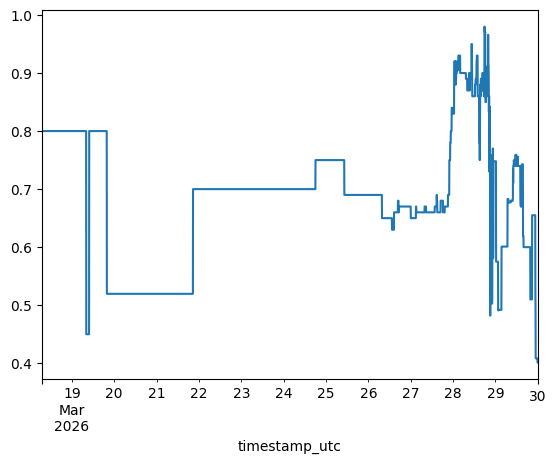

In [10]:
observation.set_index('timestamp_utc').yes_probability.plot()

In [11]:
train_target.sort_values('market_id')


,market_id,horizon_hours,label,split
6183,1001804,24,1,train
6184,1002145,24,0,train
6185,1002147,24,1,train
6186,1002166,24,1,train
6187,1002191,24,0,train
...,...,...,...,...
7747,997088,24,0,train
7748,997089,24,0,train
6211,997385,24,0,train
6212,997386,24,0,train


## Step 4: Score A Simple Baseline


Predictions are keyed by `market_id` for this single-horizon release.

Below, the baseline simply predicts `0.5` for every test market and scores that against the frozen labels.


In [12]:
# Baseline: predict 0.5 for every test market.
test_predictions = pd.DataFrame(
    {
        "market_id": test_df["market_id"],
        "pred_prob": 0.5,
    }
)
evaluation = terminal_benchmark.evaluate(test_predictions, split="test")
display(evaluation["overall"])
display(evaluation["by_horizon"])


,split,rows,log_loss,brier_score,roc_auc
0,test,2238,0.693147,0.25,0.5


,split,horizon_hours,rows,log_loss,brier_score,roc_auc
0,test,24,2238,0.693147,0.25,0.5


## Step 5: Sanity-Check The Split

Because the split is frozen on the manifest, you should usually inspect train/test counts and label balance before doing anything more expensive.


In [13]:
# The split summary is the main lightweight sanity check before modeling.
split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "examples": len(train_df),
            "targets": len(train_target),
            "positive_rate": train_target["label"].mean(),
        },
        {
            "split": "test",
            "examples": len(test_df),
            "targets": len(test_target),
            "positive_rate": test_target["label"].mean(),
        },
    ]
)
display(split_summary)

,split,examples,targets,positive_rate
0,train,7918,7918,0.225057
1,test,2238,2238,0.243074


## Step 6: Revisit Labels And Metadata

At this point you have the core objects already. This section just makes the relationship explicit:
- `targets(...)` gives you labels
- `resolve_market_id(...)` maps a benchmark row back to the frozen metadata


In [14]:
market_id = test_df.iloc[0]["market_id"]

display(train_target.head())
display(test_target.head())
display(terminal_benchmark.resolve_market_id(market_id).to_frame(name="value"))

,market_id,horizon_hours,label,split
0,517049,24,0,train
1,517050,24,1,train
2,517052,24,0,train
3,517170,24,0,train
4,517242,24,0,train


,market_id,horizon_hours,label,split
0,1004841,24,1,test
1,1004842,24,0,test
2,1004843,24,0,test
3,1007585,24,0,test
4,1020644,24,0,test


,value
market_id,1004841
market_slug,will-there-be-seven-or-eight-announced-new-us-armed-forces-strikes-against-drug-boats-by-january-31-2026
question,"Will there be seven or eight announced new U.S. armed forces strikes against drug boats by January 31, 2026?"
created_at,2025-12-23 16:45:48.990332+00:00
end_date,2026-01-31 00:00:00+00:00
platform_category,<NA>
research_category,<NA>
family_id,unknown::::there seven or eight announced new
horizon_hours,24
cutoff_timestamp_utc,2026-01-30 00:00:00+00:00


## Step 7: Summarize The Release

These summaries use only the benchmark artifacts: the frozen manifest plus normalized market histories.


In [15]:
# Summarize history lengths directly from normalized market histories.
prefix_summary = (
    terminal_benchmark.market_timeseries.groupby("market_id", dropna=False)
    .size()
    .rename("history_rows")
    .reset_index()
    .merge(
        terminal_benchmark.examples.loc[:, ["market_id", "horizon_hours", "split"]],
        on="market_id",
        how="left",
        validate="one_to_one",
    )
)

display(
    prefix_summary.groupby(["split", "horizon_hours"], dropna=False)
    .agg(
        examples=("market_id", "size"),
        mean_history_rows=("history_rows", "mean"),
        median_history_rows=("history_rows", "median"),
    )
    .reset_index()
)

,split,horizon_hours,examples,mean_history_rows,median_history_rows
0,test,24,2238,12793.964701,8958.0
1,train,24,7918,14595.794771,6919.5


## Step 8: Plot A Small Audit View

Finally, build a compact audit view of the release: how many benchmark rows are in each split, and how long the underlying market histories are on average.


These figures are derived from the benchmark release itself, not from any feature-engineered panel.


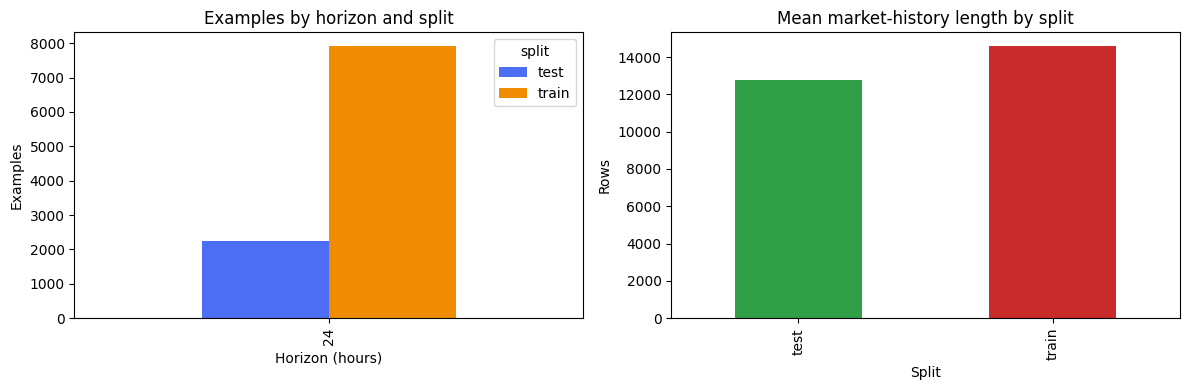

In [16]:
# Small audit plots for the release artifact.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(
    terminal_benchmark.examples.groupby(["split", "horizon_hours"]) ["market_id"]
    .size()
    .unstack("split")
    .plot(kind="bar", ax=axes[0], color=["#4C6EF5", "#F08C00"])
)
axes[0].set_title("Examples by horizon and split")
axes[0].set_xlabel("Horizon (hours)")
axes[0].set_ylabel("Examples")

(
    prefix_summary.groupby("split")["history_rows"]
    .mean()
    .plot(kind="bar", ax=axes[1], color=["#2F9E44", "#C92A2A"])
)
axes[1].set_title("Mean market-history length by split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Rows")

plt.tight_layout()